# Setup

In [1]:
from manim import *
import numpy as np
config.media_width = "75%"
config.verbosity = "WARNING"

# colors

In [ ]:
%%manim -qh Thumbnail

class Thumbnail(Scene):
    def construct(self):
        title = Tex("Title", font_size=165)
        #title.set_color_by_gradient(*gradient_colors)
        self.add(title)

# Scenes

In [2]:
%%manim -qh S1

class S1(ThreeDScene):
    def geodesic_arc(self, P, Q, center, radius, **kwargs):
        """
        Given two points P and Q on a sphere (with given center and radius),
        compute the arc along the great circle (geodesic) joining them.
        """
        # Translate points relative to the sphere's center
        P_rel = P - center
        Q_rel = Q - center
        # u is the normalized direction from center to P
        u = P_rel / np.linalg.norm(P_rel)
        # Compute a direction in the plane of the great circle:
        v = Q_rel - np.dot(Q_rel, u) * u
        v = v / np.linalg.norm(v)
        # Compute the angle between P_rel and Q_rel (this is the angular distance)
        dot_val = np.dot(P_rel/np.linalg.norm(P_rel), Q_rel/np.linalg.norm(Q_rel))
        dot_val = np.clip(dot_val, -1, 1)
        theta = np.arccos(dot_val)
        # Parametric function for the arc: center + radius*(cos(t)*u + sin(t)*v)
        arc = ParametricFunction(
            lambda t: center + radius*(np.cos(t)*u + np.sin(t)*v),
            t_range=[0, theta],
            **kwargs
        )
        return arc

    def rotate_vector(self, v, angle, axis):
        """
        Rotate vector v by angle (radians) around the given axis using Rodrigues' rotation formula.
        """
        return (v * np.cos(angle)
                + np.cross(axis, v) * np.sin(angle)
                + axis * np.dot(axis, v) * (1 - np.cos(angle)))

    def angle_arc_at_vertex(self, vertex, point1, point2, center, small_r=0.3, color=WHITE):
        """
        Create a small arc at a given vertex (on the sphere) to illustrate the interior angle.
        The arc lies in the tangent plane at the vertex. The directions are determined by
        the projections of (point1 - vertex) and (point2 - vertex) onto the tangent plane.
        """
        # Normal to the sphere at the vertex:
        normal = vertex - center
        normal = normal / np.linalg.norm(normal)
        # Compute tangent directions for each adjacent edge and project onto tangent plane.
        vec1 = point1 - vertex
        vec1 = vec1 - np.dot(vec1, normal)*normal
        tangent1 = vec1 / np.linalg.norm(vec1)
        
        vec2 = point2 - vertex
        vec2 = vec2 - np.dot(vec2, normal)*normal
        tangent2 = vec2 / np.linalg.norm(vec2)
        
        # Compute the interior angle at the vertex.
        angle = np.arccos(np.clip(np.dot(tangent1, tangent2), -1, 1))
        
        # Create the arc using rotation in the tangent plane.
        arc = ParametricFunction(
            lambda t: vertex + small_r * self.rotate_vector(tangent1, t, normal),
            t_range=[0, angle],
            color=color,
            stroke_width=4
        )
        return arc

    def construct(self):
        # Set up the 3D camera view.
        self.set_camera_orientation(phi=60 * DEGREES, theta=-45 * DEGREES)
        
        # Create the sphere centered at (-1,-3,0) with radius 2
        center = np.array([0, 0, 0])
        radius = 2
        sphere = Sphere(center=center, radius=radius, resolution=(18, 18))
        sphere.set_color(BLUE)
        self.add(sphere)
        self.wait(3)
        
        # Choose three points on the sphere to form a geodesic triangle.
        # We choose them by taking the center plus a vector of length 'radius'.
        # For example:
        #   P:  top point relative to the center (along z)
        #   Q:  point along the positive x-axis from the center
        #   R:  point along the positive y-axis from the center
        P = center + np.array([0, 0, radius])   # (-1, -3, 2)
        Q = center + np.array([radius, 0, 0])     # (1, -3, 0)
        R = center + np.array([0, -radius, 0])     # (-1, -1, 0)
        
        # Draw geodesic arcs (great circle segments) between the points.
        arc_PQ = self.geodesic_arc(P, Q, center, radius, color=RED)
        arc_QR = self.geodesic_arc(Q, R, center, radius, color=RED)
        arc_RP = self.geodesic_arc(R, P, center, radius, color=RED)
        
        triangle = VGroup(arc_PQ, arc_QR, arc_RP)
        self.play(Create(triangle), run_time=3)
        
        # --- Compute the spherical triangle's angles ---
        # Spherical distance (angular measure) between two points on the sphere.
        def spherical_distance(A, B):
            A_norm = (A - center) / radius
            B_norm = (B - center) / radius
            return np.arccos(np.clip(np.dot(A_norm, B_norm), -1, 1))

        # --- Add small arcs at each vertex to illustrate the interior angles ---
        arc_at_P = self.angle_arc_at_vertex(Q, P, R, center, small_r=0.3, color=WHITE)
        arc_at_Q = self.angle_arc_at_vertex(P, R, Q, center, small_r=0.3, color=WHITE)
        arc_at_R = self.angle_arc_at_vertex(R, Q, P, center, small_r=0.3, color=WHITE)
        
        self.play(Create(arc_at_P), Create(arc_at_Q), Create(arc_at_R))
        self.wait(2)

        self.move_camera(phi=0 * DEGREES, zoom=1.8)
        self.wait(2)
        self.move_camera(phi=60 * DEGREES, theta=-45 * DEGREES, zoom=1/1.12)

        self.wait()
        tex1 = MathTex(r"90^{\circ} + 90^{\circ} + 90^{\circ} = 270^{\circ}", r" > 180^{\circ}", font_size=80)
        tex1.move_to(DOWN*3)
        tex2 = MathTex(r"\sum \alpha_i", r" > 180^{\circ}", font_size=80).move_to(DOWN*3)
        self.add_fixed_in_frame_mobjects(tex1, tex2)
        self.remove(tex1, tex2)
        self.play(Write(tex1))
        self.wait()
        self.play(Transform(tex1, tex2))
        self.wait(2)
        self.play(FadeOut(sphere, triangle, arc_at_P, arc_at_Q, arc_at_R, tex1))

Manim Community v0.18.1

In [3]:
%%manim -qh S2

class S2(ThreeDScene):
    def construct(self):
        # Torus parameters
        R = 1.5  # major radius
        r = 0.6  # minor radius

        # Torus parametric function: (u,v) in [0,2π]×[0,2π]
        def torus(u, v):
            return np.array([
                (R + r * np.cos(v)) * np.cos(u),
                (R + r * np.cos(v)) * np.sin(u),
                r * np.sin(v)
            ])

        # Create the torus as a parametric surface
        """torus_surface = Surface(
            lambda u, v: torus(u, v),
            u_range=[0, TAU],
            v_range=[0, TAU],
            resolution=(30, 30),
            checkerboard_colors=[BLUE_D, BLUE_E],
            fill_opacity=0.5
        )"""
        torus_surface = Torus(major_radius=R, minor_radius=r).set_color(ORANGE)


        # Set up the 3D camera view
        self.set_camera_orientation(phi=75 * DEGREES, theta=30 * DEGREES, zoom=1.5)
        self.play(FadeIn(torus_surface))
        self.wait()

        # Define vertices in (u, v) parameter space:
        # Vertex A on the outer equator (v = 0)
        # Vertex B along a meridian (same u, different v)
        # Vertex C on the outer equator but with a different u value
        A_uv = (-PI/12, -PI/6)
        B_uv = (-PI/12, np.pi / 3)
        C_uv = (np.pi / 2 - PI/12, -PI/6)

        # Convert vertices to 3D points on the torus
        A = torus(*A_uv)
        B = torus(*B_uv)
        C = torus(*C_uv)

        # Mark the vertices
        dot_A = Dot3D(point=A, color=RED)
        dot_B = Dot3D(point=B, color=RED)
        dot_C = Dot3D(point=C, color=RED)
        #self.add(dot_A, dot_B, dot_C)

        # --- Define the triangle’s edges ---
        # Edge AB: With constant u (meridian). Meridians are geodesics on surfaces of revolution.
        geodesic_AB = ParametricFunction(
            lambda t: torus(A_uv[0], interpolate(A_uv[1], B_uv[1], t)),
            t_range=[0, 1],
            color=YELLOW
        )

        # Edge AC: With constant v (outer equator). The outer equator is a geodesic.
        geodesic_AC = ParametricFunction(
            lambda t: torus(interpolate(A_uv[0], C_uv[0], t), A_uv[1]),
            t_range=[0, 1],
            color=YELLOW
        )

        # Edge BC: Approximate the geodesic between B and C by linearly interpolating in (u, v).
        # (Note: This is not the exact geodesic for the torus metric.)
        geodesic_BC = ParametricFunction(
            lambda t: torus(
                interpolate(B_uv[0], C_uv[0], t),
                interpolate(B_uv[1], C_uv[1], t)
            ),
            t_range=[0, 1],
            color=YELLOW
        )

        # Animate the drawing of the geodesic triangle
        self.play(Create(geodesic_AB), Create(geodesic_AC), Create(geodesic_BC))
        self.wait(2)

        tex1 = MathTex(r"\sum \alpha_i", r" > 180^{\circ}", font_size=80).move_to(DOWN*3)
        tex1[0].set_color(YELLOW)
        self.add_fixed_in_frame_mobjects(tex1)
        self.remove(tex1)
        self.play(Write(tex1))
        self.wait()
        self.play(FadeOut(torus_surface, geodesic_AB, geodesic_AC, geodesic_BC, tex1))

Manim Community v0.18.1

In [4]:
%%manim -qh S3

class S3(ThreeDScene):
    def construct(self):
        R = 1.5  # major radius
        r = 0.6  # minor radius
        def torus(u, v):
            return np.array([
                (R + r * np.cos(v)) * np.cos(u),
                (R + r * np.cos(v)) * np.sin(u),
                r * np.sin(v)
            ])

        start = -PI/4 + PI - PI/16
        # Create the torus as a parametric surface
        torus_surface = Surface(
            lambda u, v: torus(u, v),
            u_range=[start, start + PI],
            v_range=[0, TAU],
            #resolution=(30, 30),
            fill_opacity=1            
        ).set_color(ORANGE)

        self.set_camera_orientation(phi=75 * DEGREES, theta=30 * DEGREES, zoom=1.5)
        self.play(FadeIn(torus_surface))
        self.wait()

        # Define vertices in (u, v) parameter space:
        # Vertex A on the outer equator (v = 0)
        # Vertex B along a meridian (same u, different v)
        # Vertex C on the outer equator but with a different u value
        A_uv = (np.pi + PI/16, PI/6 + PI/16)
        B_uv = (np.pi + PI/16, -np.pi / 3)
        C_uv = (np.pi / 4 + np.pi + np.pi/16 + PI/16 + PI/32, PI/6 + PI/16)

        # Convert vertices to 3D points on the torus
        A = torus(*A_uv)
        B = torus(*B_uv)
        C = torus(*C_uv)

        # Mark the vertices
        dot_A = Dot3D(point=A, color=RED)
        dot_B = Dot3D(point=B, color=RED)
        dot_C = Dot3D(point=C, color=RED)
        #self.add(dot_A, dot_B, dot_C)

        # --- Define the triangle’s edges ---
        # Edge AB: With constant u (meridian). Meridians are geodesics on surfaces of revolution.
        geodesic_AB = ParametricFunction(
            lambda t: torus(A_uv[0], interpolate(A_uv[1], B_uv[1], t)),
            t_range=[0, 1],
            color=BLUE
        )

        # Edge AC: With constant v (outer equator). The outer equator is a geodesic.
        geodesic_AC = ParametricFunction(
            lambda t: torus(interpolate(A_uv[0], C_uv[0], t), A_uv[1]),
            t_range=[0, 1],
            color=BLUE
        )

        # Edge BC: Approximate the geodesic between B and C by linearly interpolating in (u, v).
        # (Note: This is not the exact geodesic for the torus metric.)
        geodesic_BC = ParametricFunction(
            lambda t: torus(
                interpolate(B_uv[0], C_uv[0], t),
                interpolate(B_uv[1], C_uv[1], t)
            ),
            t_range=[0, 1],
            color=BLUE
        )

        # Animate the drawing of the geodesic triangle
        self.play(Create(geodesic_AB), Create(geodesic_AC), Create(geodesic_BC))
        self.wait(2)

        tex1 = MathTex(r"\sum \beta_i", r" < 180^{\circ}", font_size=80).move_to(DOWN*3)
        tex1[0].set_color(BLUE)
        self.add_fixed_in_frame_mobjects(tex1)
        self.remove(tex1)
        self.play(Write(tex1))
        self.wait()
        self.play(FadeOut(torus_surface, geodesic_AB, geodesic_AC, geodesic_BC, tex1))

Manim Community v0.18.1

In [5]:
%%manim -qh S4

class S4(ThreeDScene):
    def construct(self):
        self.set_camera_orientation(phi=75 * DEGREES, theta=-45 * DEGREES)
        # Define your surface parameterization function.
        # Replace this with your actual paper_like_surface function.
        def paper_like_surface(u, v):
            return np.array([u, np.sin(v), v])
        
        # Create the surface using your parameterization.
        paper_surface = Surface(
            paper_like_surface,
            u_range=[-2, 2],
            v_range=[-PI, PI],
            resolution=(10, 10),
            checkerboard_colors=[GREEN, GREEN_A]
        ).scale(1)
        self.play(FadeIn(paper_surface))
        
        # Set a good camera orientation.
        
        
        # Helper to get a point on the surface with the same scaling as the surface.
        def surface_point(u, v):
            # Note: because we scaled the surface, we need to scale the output as well.
            return paper_like_surface(u, v) * 1
        
        # Define vertices in parameter space (u, v)
        uv_A = (-1, -PI/2)
        uv_B = (1, -PI/2)
        uv_C = (0, PI/2)
        
        A = surface_point(*uv_A)
        B = surface_point(*uv_B)
        C = surface_point(*uv_C)
        
        # Function to approximate a geodesic between two points by interpolating in parameter space.
        # (This is only an approximation; for truly curved surfaces, you may need to solve the geodesic ODE.)
        def approximate_geodesic(uv_start, uv_end, num_points=50):
            us = np.linspace(uv_start[0], uv_end[0], num_points)
            vs = np.linspace(uv_start[1], uv_end[1], num_points)
            points = [surface_point(u, v) for u, v in zip(us, vs)]
            return VMobject().set_points_smoothly(points)
        
        # Create the three approximated curves.
        geodesic_AB = approximate_geodesic(uv_A, uv_B)
        geodesic_BC = approximate_geodesic(uv_B, uv_C)
        geodesic_CA = approximate_geodesic(uv_C, uv_A)
        
        # Group the curves into a triangle and set a color.
        geodesic_triangle = VGroup(geodesic_AB, geodesic_BC, geodesic_CA)
        geodesic_triangle.set_color(RED)
        
        # Animate the drawing of the geodesic triangle.
        self.wait()
        self.play(Create(geodesic_triangle))
        self.wait(2)

        bend = VGroup(geodesic_triangle, paper_surface)

        self.move_camera(phi=90 * DEGREES, theta=-90 * DEGREES)
        self.wait(2)

        tex1 = MathTex(r"\sum\alpha_i", r" = 180^\circ", font_size=80).to_edge(RIGHT, buff=0.1)
        tex1[0].set_color(RED)
        self.add_fixed_in_frame_mobjects(tex1)
        self.remove(tex1)
        self.play(Write(tex1))
        self.wait()
        self.play(FadeOut(bend, tex1))

Manim Community v0.18.1

In [6]:
%%manim -qh S5

class S5(ThreeDScene):
    def construct(self):
        self.set_camera_orientation(phi=75 * DEGREES, theta=-45 * DEGREES)

        # Sphere on the left
        sphere = Sphere(center=(-1, -3, 0), radius=2, resolution=(18, 18)).set_color(BLUE).shift(LEFT * 3)

        # Torus in the center
        torus = Torus(major_radius=1.5, minor_radius=0.6).set_color(ORANGE)
        
        # Isometric surface on the right (Curved but flat intrinsic curvature)
        def paper_like_surface(u, v):
            return np.array([u, np.sin(v), v])  # This can be a developable surface like a helicoid or cylinder

        paper_surface = Surface(
            paper_like_surface,
            u_range=[-2, 2],
            v_range=[-PI, PI],
            resolution=(10, 10),
            checkerboard_colors=[GREEN, GREEN_A]
        ).scale(0.7).shift(RIGHT * 4 + UP*2)

        # Add objects to scene
        self.play(FadeIn(sphere, torus, paper_surface))
        
        self.wait(3)
        self.play(FadeOut(sphere, torus, paper_surface))


Manim Community v0.18.1

In [7]:
%%manim -qh S6

class S6(Scene):
    def construct(self):
        title = Tex(r"Plane Curves", font_size=80).move_to(UP*3)

        
        # User-defined functions and parameters
        a, b = -2 * PI + 0.0001, 2*PI
        x, x_prime, x_double_prime = lambda t: t, lambda t: 1, lambda t: 0
        y, y_prime, y_double_prime = lambda t: np.sin(t), lambda t: np.cos(t), lambda t: -np.sin(t)

        # Create the parametric curve
        curve = ParametricFunction(
            lambda t: np.array([x(t), y(t), 0]),
            t_range=[a, b],
            color=BLUE
        )

        # Initialize value tracker for time parameter
        t_tracker = ValueTracker(-PI/2)
        moving_dot = Dot(color=RED).add_updater(
            lambda m: m.move_to(np.array([
                x(t_tracker.get_value()),
                y(t_tracker.get_value()),
                0
            ]))
        )
        

        # Function to calculate curvature
        def curvature(t):
            xp = x_prime(t)
            yp = y_prime(t)
            xpp = x_double_prime(t)
            ypp = y_double_prime(t)
            numerator = abs(xp * ypp - yp * xpp)
            denominator = (xp**2 + yp**2)**1.5
            return numerator / denominator if denominator != 0 else 0

        # Function to compute osculating circle center
        def compute_center(t):
            xp = x_prime(t)
            yp = y_prime(t)
            xpp = x_double_prime(t)
            ypp = y_double_prime(t)
            denominator = xp * ypp - yp * xpp
            if denominator == 0:
                return None
            speed_sq = xp**2 + yp**2
            term = speed_sq / denominator
            center_x = x(t) - yp * term
            center_y = y(t) + xp * term
            return np.array([center_x, center_y, 0])

        def osculating_circle(t):
            if curvature(t) != 0 and compute_center(t) is not None:
                return Circle(
                    radius=1 / curvature(t),
                    arc_center=compute_center(t),
                    color=WHITE,
                    stroke_width=2
                ) 
            else:
                return Line(
                    start=compute_center(t) - [x_prime(t), y_prime(t), 0] * 100,
                    end=compute_center(t) + [x_prime(t), y_prime(t), 0] * 100,
                    color=BLUE,
                    stroke_width=2
                )

        # Osculating circle (dynamically updated)
        osc_circle = always_redraw(lambda:
            osculating_circle(t_tracker.get_value())
        )

        ori = curve.copy()
        self.play(Write(title), Create(curve))
        self.wait()

        circ = Circle(radius=2.75, color=BLUE).shift(DOWN*0.5)
        c2 = Circle(radius=2, color=RED).shift(DOWN*1.25)
        line = Line(start = DOWN*3.25+LEFT*5, end = DOWN*3.25+RIGHT*5, color=WHITE)

        osctex = Tex(r"Osculating Circle", font_size=80).to_edge(DOWN)

        self.play(Transform(curve, circ))
        self.wait()
        self.play(Create(c2))
        self.play(FadeIn(line))
        self.wait()

        tex = MathTex(r"k = 1/r", font_size=80).shift(RIGHT*5)
        self.play(FadeIn(tex))
        self.wait()

        

        self.play(FadeOut(c2, line, tex), Transform(curve, ori))
        self.play(FadeIn(moving_dot, osc_circle))
        self.play(FadeIn(osctex))
        self.wait()
        
        
        # Animate the point moving along the curve
        self.play(
            t_tracker.animate.set_value(0.01),
            run_time=3,
            rate_func=linear
        )
        self.wait()
        self.play(
            t_tracker.animate.set_value(PI/2),
            run_time=1,
            rate_func=linear
        )
        self.wait(1)
        """self.play(
            t_tracker.animate.set_value(-PI/2),
            run_time=1,
            rate_func=linear
        )
        self.wait()"""

        # Distance to place the normal vectors
        normal_distance = 0.5  # Adjust as needed

        # Generate normal vectors at sampled points
        normal_vectors = VGroup()
        num_samples = 20
        for t in np.linspace(a, b, num_samples):
            # Compute position on curve
            point = np.array([x(t), y(t), 0])

            # Compute unit tangent vector
            tangent_vector = np.array([x_prime(t), y_prime(t), 0])
            tangent_vector /= np.linalg.norm(tangent_vector)

            # Compute unit normal vector (rotated -90 degrees)
            normal_vector = np.array([-tangent_vector[1], tangent_vector[0], 0])

            # Shift normal vector away from the curve
            normal_start = point
            normal_end = point + normal_distance * normal_vector

            # Create arrow
            normal_arrow = Arrow(normal_start, normal_end, buff=0, color=RED)
            normal_vectors.add(normal_arrow)

        self.play(FadeIn(normal_vectors))
        self.wait()
        self.play(
            t_tracker.animate.set_value(PI*3/2),
            run_time=1,
            rate_func=linear
        )
        self.wait()
        self.play(FadeOut(title, osctex, curve, moving_dot, osc_circle, normal_vectors))

Manim Community v0.18.1

In [9]:
%%manim -qh S7

class S7(ThreeDScene):
    def construct(self):
        # Create coordinate axes
        axes = ThreeDAxes(
            x_range=(0, 5, 1),
            y_range=(0, 5, 1),
            z_range=(-1, 1, 0.5)
        )

        # Define the hyperbolic paraboloid surface
        res = 20
        fac = 1.75
        surface = Surface(
            lambda u, v: np.array([
                u, v, (u/fac)**2 - (v/fac)**2
            ]),
            u_range=[-1.5 * fac, 1.5 * fac],
            v_range=[-1.5 * fac, 1.5 * fac],
            resolution=res,
            color=BLUE,
            fill_opacity=0.8
        )
        surface.set_fill_by_value(
            axes=axes,
            colorscale=[(RED, -0.5), (YELLOW, 0.5)],
            axis=2
        )

        # Create a dot at the point of interest (0,0,0)
        dot = Dot3D(color=RED)
        dot.z_index = 1

        # Create the normal vector (at (0,0,0), the computed normal is (0,0,1))
        normal_vector = Arrow3D(
            start=dot.get_center(),
            end=dot.get_center() + np.array([0, 0, 1]),
            color=GOLD_A
        )
        normal_vector.z_index = 1

        # Create a tracker for the rotation angle (in radians)
        theta_tracker = ValueTracker(0)

        # The rotated normal plane is given by:
        # (u*cos(theta), u*sin(theta), v)
        normal_plane = always_redraw(lambda: Surface(
            lambda u, v: np.array([
                u * np.cos(theta_tracker.get_value()),
                u * np.sin(theta_tracker.get_value()),
                v
            ]),
            u_range=[-3.5, 3.5],
            v_range=[-3.5, 3.5],
            resolution=res,
            fill_opacity=0.75
        ).set_color(BLUE))
        normal_plane.z_index=-1

        # The normal section is the intersection curve between the rotated plane and the surface.
        # For a given theta, points on the intersection satisfy:
        # (s*cos(theta), s*sin(theta), s^2/fac^2 * cos(2*theta))
        normal_section = always_redraw(lambda: ParametricFunction(
            lambda s: np.array([
                s * np.cos(theta_tracker.get_value()),
                s * np.sin(theta_tracker.get_value()),
                (s**2 / fac**2) * np.cos(2 * theta_tracker.get_value())
            ]),
            t_range=[-1.5 * fac, 1.5 * fac],
            color=PURPLE,
            stroke_width=4
        ))

        # Add text labels (optional)
        tex1 = Tex(r"normal vector").set_color(GOLD_A).to_edge(LEFT).shift(UP*2)
        tex2 = Tex(r"normal plane").set_color(BLUE).to_edge(LEFT)
        tex3 = Tex(r"normal section").set_color(PURPLE).to_edge(LEFT).shift(DOWN*2)
        tex4 = Tex(r"normal \\curvature $\kappa_n$").to_edge(RIGHT)
        
        # Set up the camera and add all mobjects
        self.set_camera_orientation(theta=110 * DEGREES, phi=70 * DEGREES)

        self.add_fixed_in_frame_mobjects(tex1, tex2, tex3, tex4)
        self.remove(tex1, tex2, tex3, tex4)

        self.play(Create(surface))
        self.wait()
        self.play(FadeIn(dot))
        self.play(Create(normal_vector), FadeIn(tex1))
        self.wait()
        self.play(Create(normal_plane), FadeIn(tex2))
        self.wait()
        self.play(Create(normal_section), FadeIn(tex3))
        self.wait()
        self.play(FadeIn(tex4))
        

        # Animate the rotation: theta goes from 0 to 90 degrees (PI/2)
        self.play(theta_tracker.animate.set_value(PI/2), run_time=3)
        self.wait(2)

        main = VGroup(surface, dot, normal_vector, normal_plane, normal_section)
        tex5 = Tex(r"principal \\curvatures\\ $k_1 \ge k_2$").to_edge(RIGHT)
        tex6 = Tex(r"gaussian curvature\\ $K = k_1 k_2$").to_edge(LEFT).shift(UP*2 + LEFT*0.2)
        tex7 = Tex(r"mean curvature \\$H = (k_1 + k_2)/2$").to_edge(LEFT).shift(DOWN*2 + LEFT*0.2)

        #self.move_camera(theta=110 * DEGREES, phi=70 * DEGREES, zoom = 0.8)


        self.play(FadeOut(tex1, tex2, tex3, tex4))
        
        self.add_fixed_in_frame_mobjects(tex5, tex6, tex7)
        self.remove(tex5, tex6, tex7)
        self.play(FadeIn(tex5))
        self.wait()
        self.play(theta_tracker.animate.set_value(0), run_time=1)
        self.wait()
        self.play(FadeIn(tex6))
        self.play(FadeIn(tex7))        
        self.wait()
        self.play(FadeOut(tex5, tex6, tex7, normal_section, normal_plane, normal_vector, surface))

Manim Community v0.18.1

In [8]:
%%manim -qh S8

class S8(ThreeDScene):
    def construct(self):
        
        
        # Set up the 3D camera view.
        self.set_camera_orientation(phi=60 * DEGREES, theta=70 * DEGREES)
        
        # Create the sphere centered at (-1,-3,0) with radius 2
        center = np.array([0, 0, 0])
        radius = 2
        sphere = Sphere(center=center, radius=radius, resolution=(18, 18), fill_opacity=0.7)
        sphere.set_color(ORANGE)

        dot = Dot3D(color=RED).move_to((0,0,2))
        dot.z_index = 1

        normal_vector = Arrow3D(
            start=dot.get_center(),
            end=dot.get_center() + np.array([0, 0, 1]),
            color=GOLD_A
        )
        normal_vector.z_index = 1
        

        normal_plane = Surface(
            lambda u, v: np.array([
                u, 0, v
            ]),
            u_range=[-3.5, 3.5],
            v_range=[-3.5, 3.5],
            resolution=20,
            fill_opacity=0.75
        ).set_color(BLUE)
        normal_plane.z_index=-1

        #circ = Circle(radius=radius).set_color(PURPLE)

        circ = ParametricFunction(
            lambda s: radius * np.array([
                np.cos(s), 0, np.sin(s)
            ]),
            t_range=[0, TAU],
            color=PURPLE,
            stroke_width=4
        )

        

        tex1 = MathTex(r"K = 1/r^2", font_size=65).to_edge(LEFT).shift(UP*0.75)
        tex2 = MathTex(r"H = -1/r", font_size=65).to_edge(LEFT).shift(DOWN*0.75) # TODO: check if sign correct

        self.play(FadeIn(sphere))
        self.wait()
        self.add(normal_plane, circ, dot, normal_vector)
        self.wait()
        self.add_fixed_in_frame_mobjects(tex1, tex2)
        self.remove(tex1, tex2)
        self.play(FadeIn(tex1, tex2))
        self.wait()
        self.play(FadeOut(sphere, normal_plane, circ, dot, normal_vector, tex1, tex2))

Manim Community v0.18.1

In [15]:
%%manim -qh S9

class S9(ThreeDScene):
    def construct(self):
        # Set up the 3D camera.
        self.set_camera_orientation(phi=60* DEGREES, theta=0 * DEGREES)
        R = 1.5  # Major radius
        r = 0.6  # Minor radius

        # Parametric definition of a torus:
        #   x = (R + r*cos(v))*cos(u)
        #   y = (R + r*cos(v))*sin(u)
        #   z = r*sin(v)
        #
        # Note: For a fixed u, v goes from 0 to TAU.
        # We divide the torus into two parts based on the sign of cos(v):
        # - Outer part: cos(v) > 0, which happens when v is between -PI/2 and PI/2.
        # - Inner part: cos(v) < 0, which is v in [PI/2, 3*PI/2].

        # Outer (red): positive Gaussian curvature region.
        outer_torus = Surface(
            lambda u, v: np.array([
                (R + r * np.cos(v)) * np.cos(u),
                (R + r * np.cos(v)) * np.sin(u),
                r * np.sin(v)
            ]),
            u_range=[0, TAU],
            v_range=[-PI/2, PI/2],
            resolution=(64, 16),
            fill_color=RED,
            fill_opacity=1,
            stroke_color=RED,
        ).set_color(RED)

        # Inner (blue): negative Gaussian curvature region.
        inner_torus = Surface(
            lambda u, v: np.array([
                (R + r * np.cos(v)) * np.cos(u),
                (R + r * np.cos(v)) * np.sin(u),
                r * np.sin(v)
            ]),
            u_range=[0, TAU],
            v_range=[PI/2, 3 * PI/2],
            resolution=(64, 16),
            fill_color=BLUE,
            fill_opacity=1,
            stroke_color=BLUE,
        ).set_color(BLUE)

        # White circles along the top and bottom where cos(v)=0 (v = PI/2 and 3PI/2).
        top_circle = ParametricFunction(
            lambda u: np.array([
                (R + r * np.cos(PI/2)) * np.cos(u),
                (R + r * np.cos(PI/2)) * np.sin(u),
                r * np.sin(PI/2)
            ]),
            t_range=[0, TAU],
            color=WHITE,
        )

        bottom_circle = ParametricFunction(
            lambda u: np.array([
                (R + r * np.cos(3 * PI/2)) * np.cos(u),
                (R + r * np.cos(3 * PI/2)) * np.sin(u),
                r * np.sin(3 * PI/2)
            ]),
            t_range=[0, TAU],
            color=WHITE,
        )

        #nocol = Torus(major_radius=R, minor_radius=r).set_color(ORANGE)

        # Group everything together.
        torus = VGroup(outer_torus, inner_torus, top_circle)

        texs = VGroup(MathTex(r"K > 0", font_size=80), MathTex(r"K = 0", font_size=80), MathTex(r"K<0", font_size=80)).arrange(DOWN).move_to(RIGHT*5)
        texs[0].set_color(RED)
        texs[2].set_color(BLUE)
        self.add_fixed_in_frame_mobjects(texs)

        #self.add(nocol)
        #self.play(Transform(nocol, torus))
        self.play(FadeIn(torus))
        self.wait(5)
        self.play(FadeOut(torus))


Manim Community v0.18.1

In [10]:
%%manim -qh S10

class S10(ThreeDScene):
    def construct(self):
        self.set_camera_orientation(phi=75 * DEGREES, theta=-45 * DEGREES)
        # Define your surface parameterization function.
        # Replace this with your actual paper_like_surface function.
        def paper_like_surface(u, v):
            return np.array([u, np.sin(v), v])
        
        # Create the surface using your parameterization.
        paper_surface = Surface(
            paper_like_surface,
            u_range=[-2, 2],
            v_range=[-PI, PI],
            resolution=(10, 10),
            checkerboard_colors=[GREEN, GREEN_A]
        ).scale(1)

        dot = Dot3D(color=RED).move_to((0,0,0))
        dot.z_index = 1

        line = ParametricFunction(
            lambda s: paper_like_surface(s, 0),
            t_range=[-2, 2],
            color=PURPLE,
            stroke_width=4
        )

        self.play(FadeIn(paper_surface))
        self.wait()
        

        tex1 = MathTex(r"K = 0", font_size=80).shift(LEFT*5)
        self.add_fixed_in_frame_mobjects(tex1)
        self.remove(tex1)

        self.play(Write(tex1))
        self.wait()
        self.play(FadeIn(dot, line))        
        self.wait()
        self.play(FadeOut(paper_surface, tex1, dot, line))

Manim Community v0.18.1

In [11]:
%%manim -qh S11

class S11(ThreeDScene):
    def construct(self):
        self.set_camera_orientation(phi=75 * DEGREES, theta=-45 * DEGREES)

        # Sphere on the left
        sphere = Sphere(center=(-1, -3, 0), radius=2, resolution=(18, 18)).set_color(BLUE).shift(LEFT * 3)

        # Torus in the center
        torus = Torus(major_radius=1.5, minor_radius=0.6).set_color(ORANGE)
        
        # Isometric surface on the right (Curved but flat intrinsic curvature)
        def paper_like_surface(u, v):
            return np.array([u, np.sin(v), v])  # This can be a developable surface like a helicoid or cylinder

        paper_surface = Surface(
            paper_like_surface,
            u_range=[-2, 2],
            v_range=[-PI, PI],
            resolution=(10, 10),
            checkerboard_colors=[GREEN, GREEN_A]
        ).scale(0.7).shift(RIGHT * 4 + UP*2)

        # Add objects to scene
        self.play(FadeIn(sphere, torus, paper_surface))

        texs1 = VGroup(MathTex(r"K > 0"), MathTex(r"\sum \alpha_i > 180^\circ")).arrange(DOWN, buff=6).shift(DOWN*0 + LEFT*5)
        texs2 = VGroup(MathTex(r"K \lessgtr 0"), MathTex(r"\sum \alpha_i \lessgtr 180^\circ")).arrange(DOWN, buff=6).shift(DOWN*0)
        texs3 = VGroup(MathTex(r"K = 0"), MathTex(r"\sum \alpha_i = 180^\circ")).arrange(DOWN, buff=6).shift(DOWN*0 + RIGHT*5)

        tex = MathTex(r"\sum \alpha_i - 180^\circ = \int_T K\,dA", font_size=70).move_to(DOWN*3)
        self.add_fixed_in_frame_mobjects(tex, texs1, texs2, texs3)
        self.remove(tex, texs1, texs2, texs3)
        self.play(FadeIn(texs1, texs2, texs3))
        
        self.wait(3)
        self.play(VGroup(texs1[1], texs2[1], texs3[1]).animate.next_to(texs2[0], DOWN, buff=0.1))
        self.play(Write(tex))
        self.wait(2)
        self.play(FadeOut(sphere, torus, paper_surface, texs1, texs2, texs3, tex))


Manim Community v0.18.1

In [12]:
%%manim -qh S12

class S12(ThreeDScene):
    def construct(self):
        tex1 = Tex(r"Gaussian curvature is an \\intrinsic property of a surface.", font_size=50).to_edge(DOWN, buff=0.1)
        title = Tex(r"Theorem Egregium", font_size=80).to_edge(UP)

        tex2 = Tex(r"An ", r"isometry", r" is an distance-preserving transformation.")
        tex2[1].set_color(RED)

        

        self.set_camera_orientation(phi=75 * DEGREES, theta=-45 * DEGREES)

        self.add_fixed_in_frame_mobjects(tex1, title, tex2)
        self.remove(tex1, title, tex2)

        def paper_like_surface(u, v):
            return np.array([u, np.sin(v), v])

        flat_surface = Surface(
            lambda u,v: [u, 0, v],
            u_range=[-2, 2],
            v_range=[-3.82, 3.82],
            resolution=(10, 10),
            checkerboard_colors=[GREEN, GREEN_A]
        ).scale(0.7)

        paper_surface = Surface(
            paper_like_surface,
            u_range=[-2, 2],
            v_range=[-PI, PI],
            resolution=(10, 10),
            checkerboard_colors=[GREEN, GREEN_A]
        ).scale(0.7)
        
        self.play(Write(tex1))
        self.wait()
        self.play(FadeIn(paper_surface))
        self.wait()
        self.play(ReplacementTransform(paper_surface, flat_surface))
        self.wait()
        self.play(FadeIn(title))
        self.wait()
        self.play(FadeOut(tex1, flat_surface, title))
        

Manim Community v0.18.1

In [13]:
%%manim -qh S13

class S13(ThreeDScene):
    def construct(self):
        # Set up 3D camera orientation
        self.set_camera_orientation(phi=75 * DEGREES, theta=0 * DEGREES)
        
        ##############################
        # Part 1: Rectangle & Flat Surface
        ##############################
        # Create a rectangle (its boundary)
        rect = Rectangle(width=4, height=3, color=BLUE)
        # Create a flat surface filling the rectangle.
        # We map (u,v) in [0,1]x[0,1] to the rectangle coordinates.
        flat_surface = Surface(
            lambda u, v: np.array([
                4*(u - 0.5),   # x from -2 to 2
                3*(v - 0.5),   # y from -1.5 to 1.5
                0              # flat in z
            ]),
            u_range=[0, 1],
            v_range=[0, 1],
            checkerboard_colors=[BLUE_D, BLUE_E],
            resolution=(15, 15)
        )
        flat_surface.set_opacity(0.75)
        flat = VGroup(rect, flat_surface).scale(1.5).shift((0,-3, 0))

        curved = VGroup(
            Surface(lambda u,v: np.array([
                4*(u - 0.5),
                3*(v - 0.5),
                0.2*np.sin(10*v)
            ]), u_range=[0,1], v_range=[0,1],checkerboard_colors=[BLUE_D, BLUE_E],
            resolution=(15, 15), fill_opacity=0.75)
        ).scale(1.5).shift((0,3,0))
        
        # Animate the rectangle and then fill it in with the flat minimal surface.
        """self.play(Create(rect))
        self.wait(0.5)
        self.play(FadeIn(flat_surface, run_time=2))
        self.wait(1)
        self.play(FadeOut(flat_surface), FadeOut(rect))"""
        
        ##############################
        # Part 2: Two Circles & Catenoid
        ##############################
        # Define two circles at z = -1 and z = 1.
        # For a catenoid with v in [-1,1], the circles have radius cosh(1).
        r_boundary = np.cosh(1)
        circle1 = Circle(radius=r_boundary, color=GREEN).move_to(np.array([0, 0, -1]))
        circle2 = Circle(radius=r_boundary, color=GREEN).move_to(np.array([0, 0, 1]))
        
        # Define the catenoid as a parametric surface:
        catenoid = Surface(
            lambda u, v: np.array([
                np.cosh(v) * np.cos(u),
                np.cosh(v) * np.sin(u),
                v
            ]),
            u_range=[0, TAU],
            v_range=[-1, 1],
            resolution=(30, 15),
            checkerboard_colors=[GREEN_D, GREEN_E]
        )
        catenoid.set_opacity(0.75)

        cat = VGroup(circle1, circle2, catenoid).scale(1.5).shift((0,3,0))
        
        """self.play(Create(circle1), Create(circle2))
        self.wait(0.5)
        self.play(FadeIn(catenoid, run_time=2))
        self.wait(1)
        self.play(FadeOut(catenoid), FadeOut(circle1), FadeOut(circle2))"""

        

        tex1 = Tex(r"Mean curvature is an extrensic property of a surface.", font_size=55).to_edge(UP)
        tex2 = MathTex(r"H=0", font_size=80).move_to(LEFT*3.5 + DOWN*2.5)
        tex3 = MathTex(r"H \ne 0", font_size=80).move_to(RIGHT*3.5 + DOWN*2.5)
        tex4 = Tex(r"Surfaces with zero mean curvature are minimal surfaces.", font_size=50).to_edge(UP)
        self.add_fixed_in_frame_mobjects(tex1, tex2, tex3, tex4)
        self.remove(tex1, tex2, tex3, tex4)

        self.play(FadeIn(tex1))
        self.wait()
        self.play(FadeIn(curved, flat[1], tex2, tex3))
        self.wait()
        self.play(FadeOut(curved, flat[1], tex2, tex3, tex1))
        self.play(FadeIn(tex4))
        self.wait()
        self.play(Create(flat[0]))
        self.wait(0.5)
        self.play(FadeIn(flat[1]))
        self.wait()
        self.play(Create(cat[0:2]))
        self.wait(0.5)
        self.play(FadeIn(cat[2]))
        self.wait()
        self.play(FadeOut(tex4, flat, cat))        


Manim Community v0.18.1

In [ ]:
%%manim -qm NormalVectorScene

# Define the parametric surface function.
def surface_func(u, v):
    # A surface with varying curvature. (u,v) in parameter space.
    # Here we use: (x, y, z) = (u, v, 0.3*sin(u)*cos(v))
    return np.array([u, v, 0.3 * np.sin(u) * np.cos(v)])

# Partial derivatives for computing the normal.
def d_surface_du(u, v):
    # Derivative with respect to u: (1, 0, 0.3*cos(u)*cos(v))
    return np.array([1, 0, 0.3 * np.cos(u) * np.cos(v)])

def d_surface_dv(u, v):
    # Derivative with respect to v: (0, 1, -0.3*sin(u)*sin(v))
    return np.array([0, 1, -0.3 * np.sin(u) * np.sin(v)])

class NormalVectorScene(ThreeDScene):
    def construct(self):
        # Set up the 3D camera.
        self.set_camera_orientation(phi=75 * DEGREES, theta=-45 * DEGREES)

        # Create the left surface (shifted to the left).
        surface = Surface(
            lambda u, v: surface_func(u, v) + np.array([-3, 0, 0]),
            u_range=[-2, 2],
            v_range=[-2, 2],
            resolution=(10, 10),
            checkerboard_colors=[BLUE_D, BLUE_E],
            stroke_color=WHITE,
            stroke_width=0.5,
        )
        surface.set_transparency(0.7)

        # Create the right unit sphere.
        sphere = Sphere(radius=1, center=np.array([3, 0, 0]), resolution=10, u_range=[0, TAU])
        sphere.set_style(fill_opacity=0.5, stroke_color=WHITE)

        # Add both surfaces to the scene.
        self.add(surface, sphere)

        # Create a dot that will move along a path on the surface.
        moving_dot = Dot3D(point=ORIGIN, color=YELLOW, radius=0.05)
        self.add(moving_dot)

        # Create arrows for the normal on the surface and on the sphere.
        # They are defined as always_redraw so they update each frame.
        normal_arrow = always_redraw(lambda: self.get_normal_arrow(moving_dot.get_center(), surface))
        sphere_normal_arrow = always_redraw(lambda: self.get_sphere_normal_arrow(moving_dot.get_center(), surface))
        self.add(normal_arrow, sphere_normal_arrow)

        # Define a path on the surface. For simplicity, let v = 0 and u goes from -2 to 2.
        path = VMobject()
        path.set_points_smoothly([surface_func(u, 0) + np.array([-3, 0, 0]) for u in np.linspace(-2, 2, 100)])
        moving_dot.move_to(path.get_start())

        self.play(Create(path), run_time=2)
        self.play(MoveAlongPath(moving_dot, path, run_time=6, rate_func=linear))
        self.wait()

    def get_normal_arrow(self, dot_point, surface):
        # We need to extract the (u, v) parameters corresponding to the dot's location.
        # Since the dot lies on the surface defined by S(u,v)+(-3,0,0), we invert the shift.
        point_local = dot_point + np.array([3, 0, 0])
        # Here we assume v is 0 along the path, and u is the x-coordinate.
        u_val = point_local[0]
        v_val = 0

        # Compute the partial derivatives.
        S_u = d_surface_du(u_val, v_val)
        S_v = d_surface_dv(u_val, v_val)
        # Normal is given by the cross product (order chosen for outward orientation).
        normal = np.cross(S_u, S_v)
        # Normalize the normal vector.
        normal_unit = normal / np.linalg.norm(normal)

        # Arrow originates at the dot and points in the normal direction.
        arrow_length = 1  # adjust for visual clarity
        return Arrow3D(
            start=dot_point,
            end=dot_point + arrow_length * normal_unit,
            color=RED,
            stroke_width=4,
            #buff=0,
        )

    def get_sphere_normal_arrow(self, dot_point, surface):
        # This arrow shows the same normal unit vector on the sphere.
        # We compute the normal at the same (u,v) as above.
        point_local = dot_point + np.array([3, 0, 0])
        u_val = point_local[0]
        v_val = 0
        S_u = d_surface_du(u_val, v_val)
        S_v = d_surface_dv(u_val, v_val)
        normal = np.cross(S_u, S_v)
        normal_unit = normal / np.linalg.norm(normal)
        # On the sphere, the arrow starts at the sphere center (3,0,0) and ends on its surface.
        sphere_center = np.array([3, 0, 0])
        arrow_length = 1  # since the sphere has radius 1
        return Arrow3D(
            start=sphere_center,
            end=sphere_center + arrow_length * normal_unit,
            color=GREEN,
            stroke_width=4,
            #buff=0,
        )


# Drafts

In [10]:
%%manim -qm TestST

class TestST(Scene):
    def construct(self):
        # User-defined functions and parameters
        a, b = -2 * PI + 0.0001, 2*PI
        x, x_prime, x_double_prime = lambda t: t, lambda t: 1, lambda t: 0
        y, y_prime, y_double_prime = lambda t: np.sin(t), lambda t: np.cos(t), lambda t: -np.sin(t)
        #def y_double_prime(t):
        #    return -np.sin(t)

        #a, b = -4, 4
        #x, x_prime, x_double_prime = lambda t: t, lambda t: 1, lambda t: 0
        #y, y_prime, y_double_prime = lambda t: t**2, lambda t: 2*t, lambda t: 2

        #c = 10
        #a, b = -2, 5
        #x, x_prime, x_double_prime = lambda t: (t**3 - 5*t**2 + 3*t + 2)/c, lambda t: (3*t**2 - 10*t + 3)/c, lambda t: (6*t - 10)/c
        #y, y_prime, y_double_prime = lambda t: (t**2 - 2*t - 2)/c, lambda t: (2*t - 2)/c, lambda t: 2/c

        #a, b = 0+0.0001, 2*PI
        #x, x_prime, x_double_prime = lambda t: np.sin(2*t), lambda t: 2*np.cos(2*t), lambda t: -4*np.sin(2*t)
        #y, y_prime, y_double_prime = lambda t: np.sin(3*t), lambda t: 3*np.cos(3*t), lambda t: -9*np.sin(3*t)

        """a, b = 0, 4*PI
        x = lambda t: np.cos(t) * (1 + 0.5 * np.cos(5/2 * t))
        y = lambda t: np.sin(t) * (1 + 0.5 * np.cos(5/2 * t))
        
        # First derivatives of the parametric equations
        x_prime = lambda t: -np.sin(t) * (1 + 0.5 * np.cos(5/2 * t)) - 1.25 * np.cos(t) * np.sin(5/2 * t)
        y_prime = lambda t: np.cos(t) * (1 + 0.5 * np.cos(5/2 * t)) - 1.25 * np.sin(t) * np.sin(5/2 * t)
        
        # Second derivatives of the parametric equations
        x_double_prime = lambda t: -np.cos(t) * (1 + 0.5 * np.cos(5/2 * t)) - 1.25 * np.sin(t) * np.sin(5/2 * t) - 1.25 * np.cos(t) * np.cos(5/2 * t)
        y_double_prime = lambda t: -np.sin(t) * (1 + 0.5 * np.cos(5/2 * t)) - 1.25 * np.cos(t) * np.sin(5/2 * t) - 1.25 * np.sin(t) * np.cos(5/2 * t)
        """

        # Create the parametric curve
        curve = ParametricFunction(
            lambda t: np.array([x(t), y(t), 0]),
            t_range=[a, b],
            color=WHITE
        )
        self.add(curve)

        # Initialize value tracker for time parameter
        t_tracker = ValueTracker(a)
        moving_dot = Dot(color=RED).add_updater(
            lambda m: m.move_to(np.array([
                x(t_tracker.get_value()),
                y(t_tracker.get_value()),
                0
            ]))
        )
        self.add(moving_dot)

        # Function to calculate curvature
        def curvature(t):
            xp = x_prime(t)
            yp = y_prime(t)
            xpp = x_double_prime(t)
            ypp = y_double_prime(t)
            numerator = abs(xp * ypp - yp * xpp)
            denominator = (xp**2 + yp**2)**1.5
            return numerator / denominator if denominator != 0 else 0

        # Function to compute osculating circle center
        def compute_center(t):
            xp = x_prime(t)
            yp = y_prime(t)
            xpp = x_double_prime(t)
            ypp = y_double_prime(t)
            denominator = xp * ypp - yp * xpp
            if denominator == 0:
                return None
            speed_sq = xp**2 + yp**2
            term = speed_sq / denominator
            center_x = x(t) - yp * term
            center_y = y(t) + xp * term
            return np.array([center_x, center_y, 0])

        def osculating_circle(t):
            if curvature(t) != 0 and compute_center(t) is not None:
                return Circle(
                    radius=1 / curvature(t),
                    arc_center=compute_center(t),
                    color=BLUE,
                    stroke_width=2
                ) 
            else:
                return Line(
                    start=compute_center(t) - [x_prime(t), y_prime(t), 0] * 100,
                    end=compute_center(t) + [x_prime(t), y_prime(t), 0] * 100,
                    color=BLUE,
                    stroke_width=2
                )

        # Osculating circle (dynamically updated)
        osc_circle = always_redraw(lambda:
            osculating_circle(t_tracker.get_value())
        )
        self.add(osc_circle)

        # Animate the point moving along the curve
        self.play(
            t_tracker.animate.set_value(b),
            run_time=10,
            rate_func=linear
        )

Manim Community v0.18.1

In [23]:
%%manim -qh ShapeLine

from manim import *
import numpy as np

class ShapeLine(Scene):
    def construct(self):
        # --- Bump Curve Setup ---
        def curve_func(x):
            # Modified bump curve with additional oscillations
            return 2 * np.exp(-7 * x**2) + 0.02*np.sin(7*x) + 0.02*np.cos(6*x)
        
        # Parameters for reparameterization
        x_min, x_max = -5, 5
        num_points = 1000
        xs = np.linspace(x_min, x_max, num_points)
        ys = curve_func(xs)
        # Apply vertical shift to match the drawn curve (UP*0.7)
        points = np.stack([xs, ys + 0.7], axis=1)
        # Compute distances between consecutive points to approximate arc length
        distances = np.linalg.norm(np.diff(points, axis=0), axis=1)
        cumulative = np.concatenate(([0], np.cumsum(distances)))
        total_length = cumulative[-1]
        
        # Create the bump curve using the original parameterization (for display)
        curve = FunctionGraph(curve_func, x_range=[x_min, x_max], color=BLUE).shift(UP*0.7)
        self.play(Create(curve))
        
        # Helper: Given an arc length s, return the corresponding x value by interpolation
        def x_from_s(s):
            return np.interp(s, cumulative, xs)
        
        # ValueTracker for arc-length parameter (instead of x)
        arc_length_tracker = ValueTracker(0)
        
        # Dot that always updates its position along the curve (constant speed)
        moving_dot = always_redraw(lambda: Dot(
            point=np.array([
                x_from_s(arc_length_tracker.get_value()),
                curve_func(x_from_s(arc_length_tracker.get_value())) + 0.7,
                0
            ]),
            color=RED
        ))
        
        # Arrow on the curve that always updates to show the unit normal vector
        normal_arrow = always_redraw(lambda: self.get_normal_arrow(
            x_from_s(arc_length_tracker.get_value()), curve_func, shift=0.7
        ))
        
        #self.play(FadeIn(moving_dot, normal_arrow))
        
        # --- Gauss Map Setup ---
        # Create a unit circle to represent the Gauss map.
        # Its center is fixed so that the arrow (Gauss map) always originates at the center.
        circle_center = RIGHT*4 + UP*2
        unit_circle = Circle(radius=1, color=GREEN).move_to(circle_center)
        #self.play(Create(unit_circle))
        
        # Dot at the center of the unit circle (fixed)
        center_dot = Dot(point=circle_center, color=WHITE)
        
        # Gauss map arrow: from the center of the unit circle to its circumference,
        # using the unit normal vector from the bump curve.
        gauss_arrow = always_redraw(lambda: Arrow(
            circle_center,
            circle_center + self.get_unit_normal(
                x_from_s(arc_length_tracker.get_value()), curve_func
            ),
            buff=0,
            color=YELLOW
        ))
        
        # Add a text label to indicate the Gauss map.
        gauss_text = Tex(r"Gauss Map $n: X \to S^1$", font_size=50).next_to(unit_circle, UP)
        
        #self.play(FadeIn(center_dot, gauss_arrow, gauss_text))
        
        # Animate the dot along the curve at constant speed
        #self.play(arc_length_tracker.animate.set_value(total_length), run_time=5, rate_func=linear)
        #self.wait(1)
        #self.play(arc_length_tracker.animate.set_value(0), run_time=5, rate_func=linear)

        dot = Dot(color=RED).shift(UP*0.7 + curve_func(0)*UP)
        self.play(FadeIn(dot))
        line = Line(start = UP*0.7 + curve_func(0)*UP + LEFT*4, end=UP*0.7 + curve_func(0)*UP + RIGHT*4).set_color(GREEN)
        tanlab = MathTex(r"T_pX").set_color(GREEN).next_to(line, RIGHT)
        self.play(FadeIn(line, tanlab))
        vec1 = Arrow(start = UP*0.7 + curve_func(0)*UP, end = UP*0.7 + curve_func(0)*UP + RIGHT*1, buff=0).set_color(YELLOW)
        label = MathTex(r"v").next_to(vec1, UP).set_color(YELLOW)
        vec2 = Arrow(start = UP*0.7 + curve_func(0)*UP, end = UP*0.7 + curve_func(0)*UP + RIGHT*3, buff=0).set_color(YELLOW)
        label2 = MathTex(r"S_p(v)").next_to(vec1, UP).set_color(YELLOW)
        self.play(FadeIn(vec1, label))
        self.wait()
        self.play(Transform(vec1, vec2), Transform(label, label2))
        self.wait()
        final = MathTex(r"S_p(v) = kv", font_size=80).shift(DOWN*2)
        final2 = Tex(r"Curvature $k$ at $p$ is the eigenvalue of $S_p$", font_size=50).next_to(final, DOWN)
        self.play(Write(final))
        self.wait()
        self.play(Write(final2))
        self.wait()

        
    def get_normal_arrow(self, x, func, shift=0):
        # Compute the unit normal at a point on the bump curve for the on-curve arrow
        eps = 1e-5
        f_x = func(x)
        f_prime = (func(x + eps) - func(x - eps)) / (2 * eps)
        tangent = np.array([1, f_prime, 0])
        tangent_unit = tangent / np.linalg.norm(tangent)
        # Normal vector: rotate tangent 90° counterclockwise
        normal_unit = np.array([-tangent_unit[1], tangent_unit[0], 0])
        pos = np.array([x, f_x + shift, 0])
        return Arrow(pos, pos + normal_unit, buff=0, color=YELLOW)
    
    def get_unit_normal(self, x, func):
        # Compute and return the unit normal vector from the bump curve (for the Gauss map)
        eps = 1e-5
        f_prime = (func(x + eps) - func(x - eps)) / (2 * eps)
        tangent = np.array([1, f_prime, 0])
        tangent_unit = tangent / np.linalg.norm(tangent)
        normal_unit = np.array([-tangent_unit[1], tangent_unit[0], 0])
        return normal_unit  # Already unit-length


Manim Community v0.18.1

In [31]:
%%manim -qh ShapeSurface

class ShapeSurface(Scene):
    def construct(self):
        title = Tex(r"Shape operator $S_p$ for a surface", font_size=70).to_edge(UP)
        prin = Tex(r"Eigenvalues of $S_p$ \\are principal curvatures").shift(DOWN*0 + LEFT*3.5)
        gauss = Tex(r"Gaussian curvature \\$K = \det(S_p)$").shift(DOWN*2)
        mean = Tex(r"Mean curvature \\$H = \frac{1}{2} \operatorname{Tr}(S_p)$").shift(DOWN*0 + RIGHT*3.5)

        arr1 = Arrow(start = title.get_center(), end = prin.get_center(), buff=0.75)
        arr2 = Arrow(start = title.get_center(), end = gauss.get_center(), buff=0.5)
        arr3 = Arrow(start = title.get_center(), end = mean.get_center(), buff=0.75)

        self.play(FadeIn(title))
        self.wait()
        self.play(FadeIn(prin, arr1))
        self.play(FadeIn(gauss, arr2))
        self.play(FadeIn(mean, arr3))
        self.wait()
        self.play(FadeOut(title, prin, gauss, mean, arr1, arr2, arr3))
        

Manim Community v0.18.1

# Thumbnail

Manim Community v0.18.1

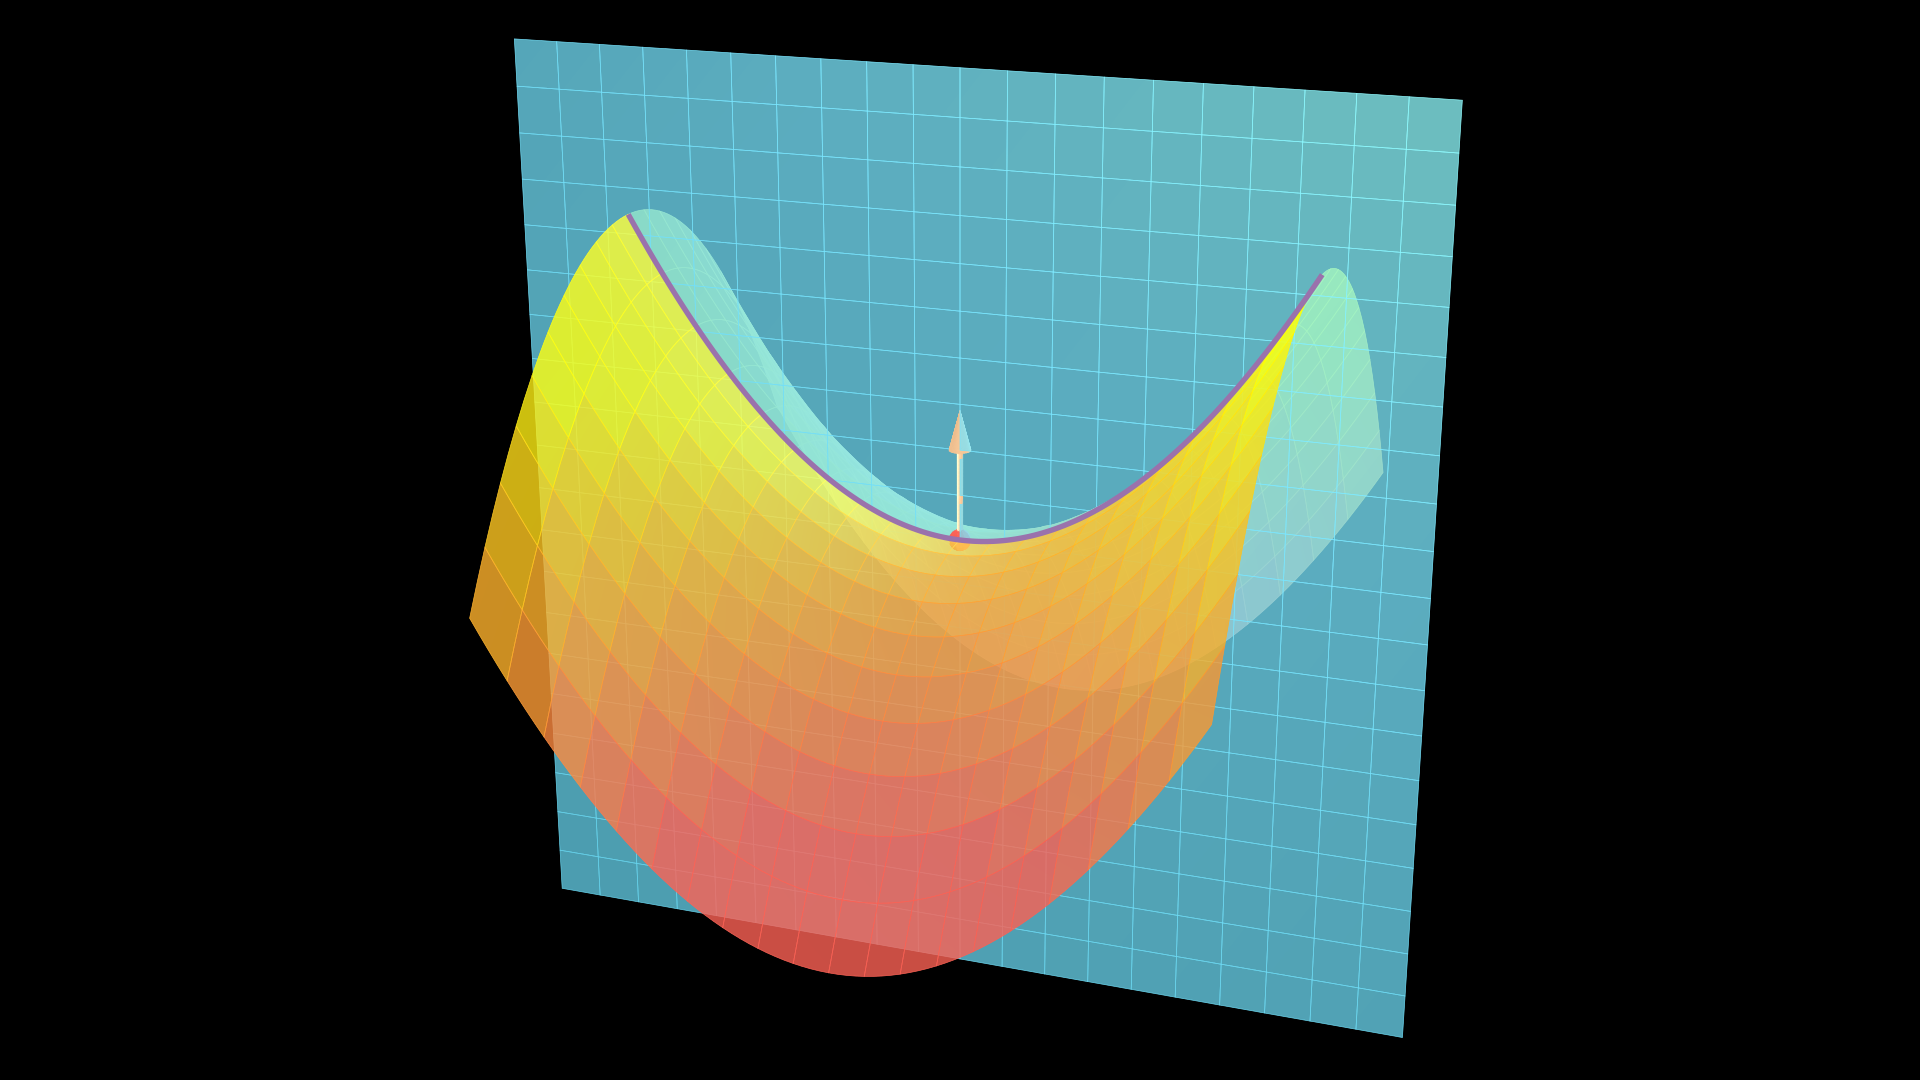

In [34]:
%%manim -qh T1

class T1(ThreeDScene):
    def construct(self):
        # Create coordinate axes
        axes = ThreeDAxes(
            x_range=(0, 5, 1),
            y_range=(0, 5, 1),
            z_range=(-1, 1, 0.5)
        )

        # Define the hyperbolic paraboloid surface
        res = 20
        fac = 1.75
        surface = Surface(
            lambda u, v: np.array([
                u, v, (u/fac)**2 - (v/fac)**2
            ]),
            u_range=[-1.5 * fac, 1.5 * fac],
            v_range=[-1.5 * fac, 1.5 * fac],
            resolution=res,
            color=BLUE,
            fill_opacity=0.8
        )
        surface.set_fill_by_value(
            axes=axes,
            colorscale=[(RED, -0.5), (YELLOW, 0.5)],
            axis=2
        )

        # Create a dot at the point of interest (0,0,0)
        dot = Dot3D(color=RED)
        dot.z_index = 1

        # Create the normal vector (at (0,0,0), the computed normal is (0,0,1))
        normal_vector = Arrow3D(
            start=dot.get_center(),
            end=dot.get_center() + np.array([0, 0, 1]),
            color=GOLD_A
        )
        normal_vector.z_index = 2

        # Create a tracker for the rotation angle (in radians)
        theta_tracker = ValueTracker(0)

        # The rotated normal plane is given by:
        # (u*cos(theta), u*sin(theta), v)
        normal_plane = always_redraw(lambda: Surface(
            lambda u, v: np.array([
                u * np.cos(theta_tracker.get_value()),
                u * np.sin(theta_tracker.get_value()),
                v
            ]),
            u_range=[-3.5, 3.5],
            v_range=[-3.5, 3.5],
            resolution=res,
            fill_opacity=0.75
        ).set_color(BLUE))
        normal_plane.z_index=-1

        # The normal section is the intersection curve between the rotated plane and the surface.
        # For a given theta, points on the intersection satisfy:
        # (s*cos(theta), s*sin(theta), s^2/fac^2 * cos(2*theta))
        normal_section = always_redraw(lambda: ParametricFunction(
            lambda s: np.array([
                s * np.cos(theta_tracker.get_value()),
                s * np.sin(theta_tracker.get_value()),
                (s**2 / fac**2) * np.cos(2 * theta_tracker.get_value())
            ]),
            t_range=[-1.5 * fac, 1.5 * fac],
            color=PURPLE,
            stroke_width=4
        ))

        # Add text labels (optional)
        tex1 = Tex(r"normal vector").set_color(GOLD_A).to_edge(LEFT).shift(UP*2)
        tex2 = Tex(r"normal plane").set_color(BLUE).to_edge(LEFT)
        tex3 = Tex(r"normal section").set_color(PURPLE).to_edge(LEFT).shift(DOWN*2)
        tex4 = Tex(r"normal \\curvature $\kappa_n$").to_edge(RIGHT)
        
        # Set up the camera and add all mobjects
        self.set_camera_orientation(theta=110 * DEGREES, phi=70 * DEGREES)

        self.add_fixed_in_frame_mobjects(tex1, tex2, tex3, tex4)
        self.remove(tex1, tex2, tex3, tex4)

        self.add(surface, dot, normal_vector, normal_plane, normal_section)
        
        

Manim Community v0.18.1

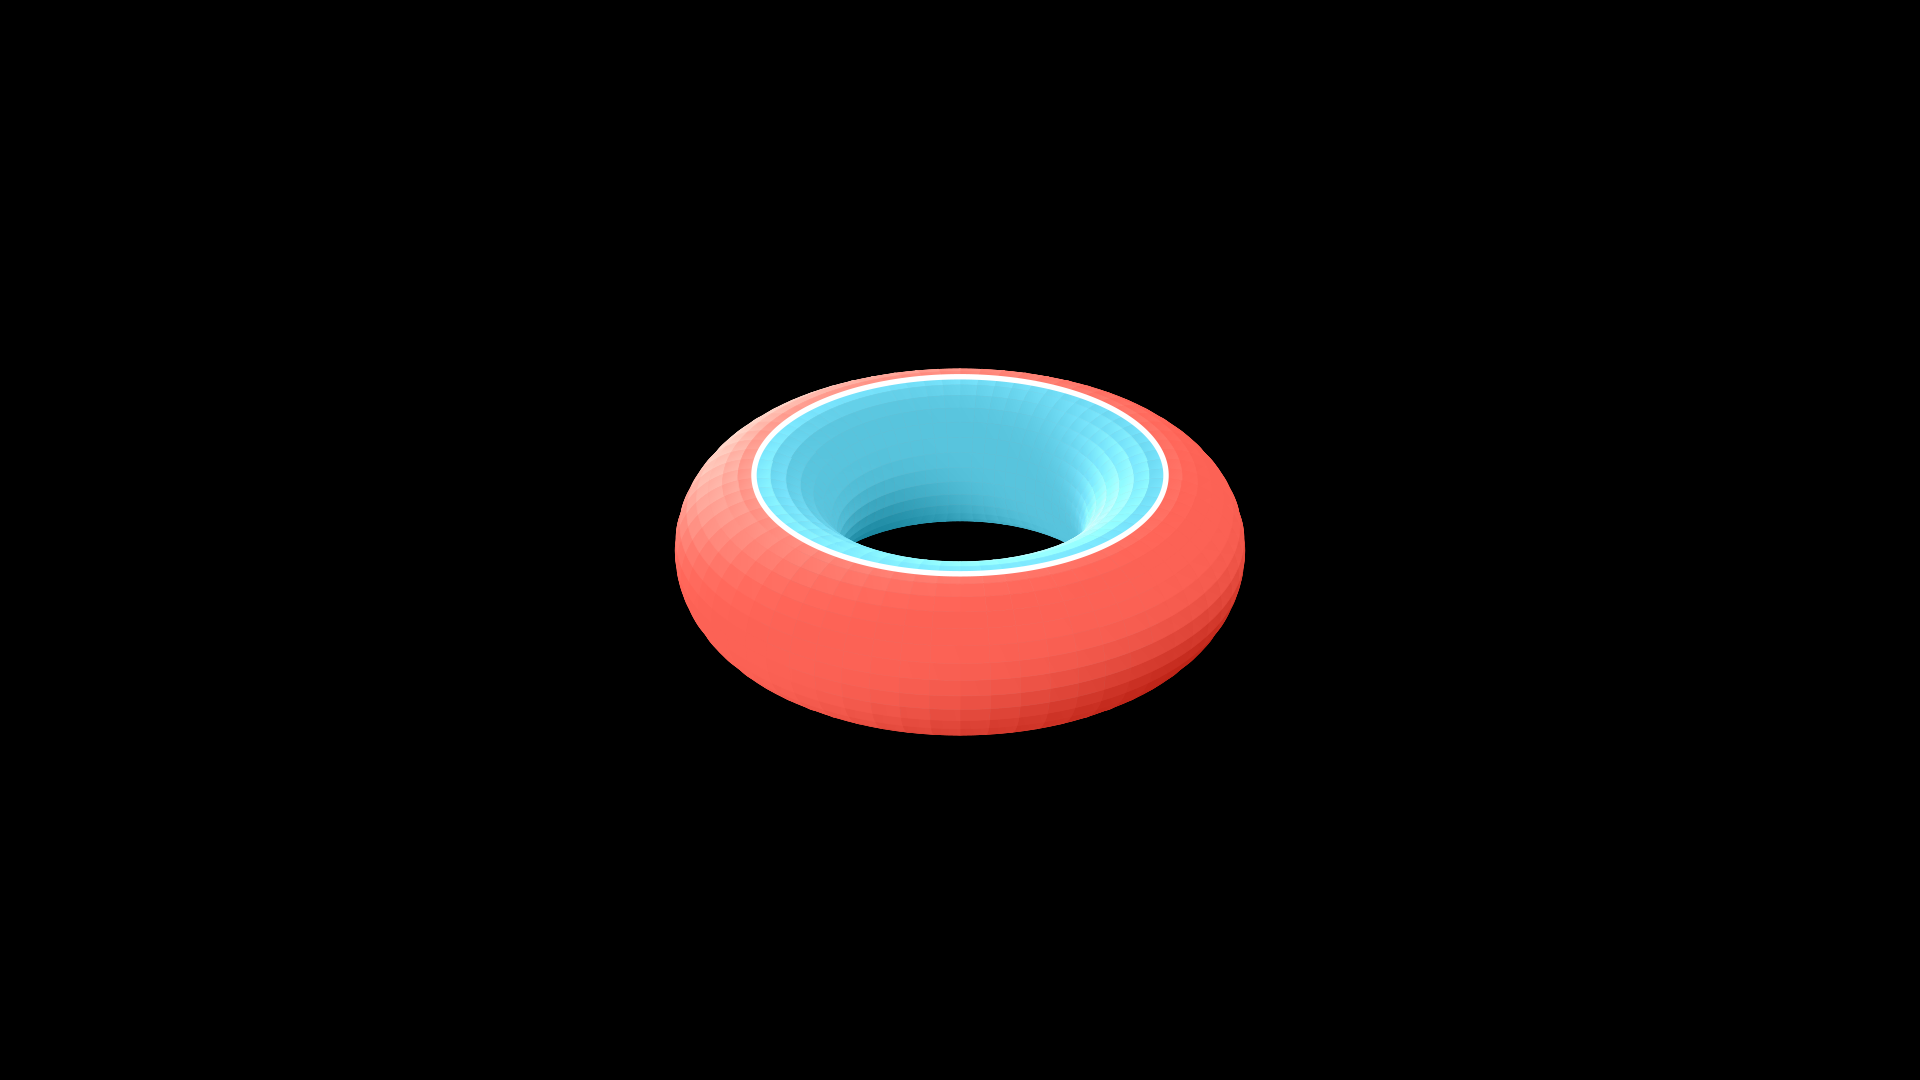

In [35]:
%%manim -qh T2

class T2(ThreeDScene):
    def construct(self):
        # Set up the 3D camera.
        self.set_camera_orientation(phi=60* DEGREES, theta=0 * DEGREES)
        R = 1.5  # Major radius
        r = 0.6  # Minor radius

        # Parametric definition of a torus:
        #   x = (R + r*cos(v))*cos(u)
        #   y = (R + r*cos(v))*sin(u)
        #   z = r*sin(v)
        #
        # Note: For a fixed u, v goes from 0 to TAU.
        # We divide the torus into two parts based on the sign of cos(v):
        # - Outer part: cos(v) > 0, which happens when v is between -PI/2 and PI/2.
        # - Inner part: cos(v) < 0, which is v in [PI/2, 3*PI/2].

        # Outer (red): positive Gaussian curvature region.
        outer_torus = Surface(
            lambda u, v: np.array([
                (R + r * np.cos(v)) * np.cos(u),
                (R + r * np.cos(v)) * np.sin(u),
                r * np.sin(v)
            ]),
            u_range=[0, TAU],
            v_range=[-PI/2, PI/2],
            resolution=(64, 16),
            fill_color=RED,
            fill_opacity=1,
            stroke_color=RED,
        ).set_color(RED)

        # Inner (blue): negative Gaussian curvature region.
        inner_torus = Surface(
            lambda u, v: np.array([
                (R + r * np.cos(v)) * np.cos(u),
                (R + r * np.cos(v)) * np.sin(u),
                r * np.sin(v)
            ]),
            u_range=[0, TAU],
            v_range=[PI/2, 3 * PI/2],
            resolution=(64, 16),
            fill_color=BLUE,
            fill_opacity=1,
            stroke_color=BLUE,
        ).set_color(BLUE)

        # White circles along the top and bottom where cos(v)=0 (v = PI/2 and 3PI/2).
        top_circle = ParametricFunction(
            lambda u: np.array([
                (R + r * np.cos(PI/2)) * np.cos(u),
                (R + r * np.cos(PI/2)) * np.sin(u),
                r * np.sin(PI/2)
            ]),
            t_range=[0, TAU],
            color=WHITE,
        )

        bottom_circle = ParametricFunction(
            lambda u: np.array([
                (R + r * np.cos(3 * PI/2)) * np.cos(u),
                (R + r * np.cos(3 * PI/2)) * np.sin(u),
                r * np.sin(3 * PI/2)
            ]),
            t_range=[0, TAU],
            color=WHITE,
        )

        #nocol = Torus(major_radius=R, minor_radius=r).set_color(ORANGE)

        # Group everything together.
        torus = VGroup(outer_torus, inner_torus, top_circle)

        texs = VGroup(MathTex(r"K > 0", font_size=80), MathTex(r"K = 0", font_size=80), MathTex(r"K<0", font_size=80)).arrange(DOWN).move_to(RIGHT*5)
        texs[0].set_color(RED)
        texs[2].set_color(BLUE)
        #self.add_fixed_in_frame_mobjects(texs)

        #self.add(nocol)
        #self.play(Transform(nocol, torus))s
        self.add(torus)


Manim Community v0.18.1

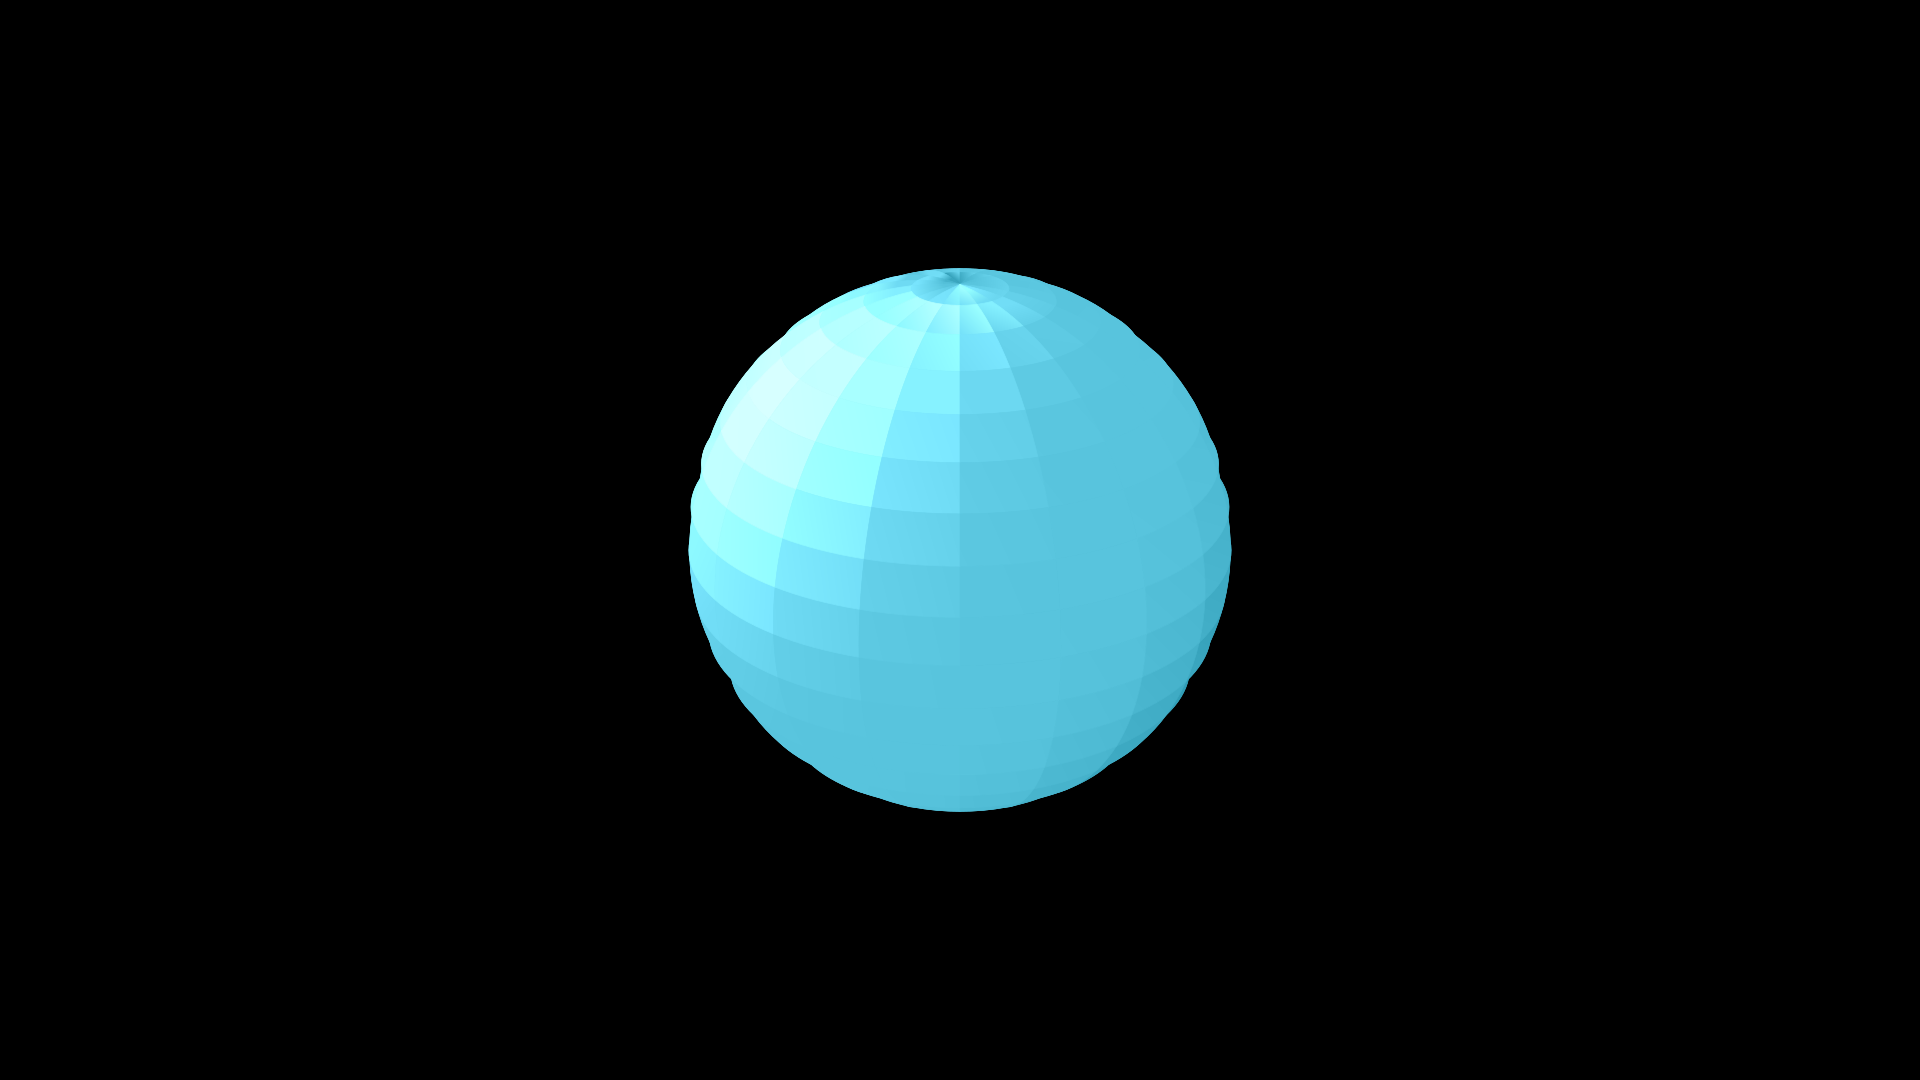

In [45]:
%%manim -qh T3

class T3(ThreeDScene):
    def construct(self):
        self.set_camera_orientation(phi=65 * DEGREES, theta=-60 * DEGREES)

        sphere = Sphere(center=ORIGIN, radius=2, resolution=(18, 18)).set_color(BLUE)
        self.add(sphere)